In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [2]:
sales = pd.read_csv('data/sales.csv')
items = pd.read_csv('data/items.csv')

# 1. Data Type Conversion
sales['date'] = pd.to_datetime(sales['date'])

# 2. Merge Tables
# It is critical to do a left join on sales to keep every transaction
df = sales.merge(items, on='item_name', how='left')

df.head()

,date,time,item_name,transaction_type,own_cup,surcharge,customer_id,price,production_cost,item_type,drink_temperature,drink_type
0,2022-01-01,07:03:30,Cold Brew,Takeout,True,False,26946,4.75,1.35,Drink,Cold,Coffee
1,2022-01-01,07:30:58,Iced Coffee,Takeout,True,False,24356,4.00,1.10,Drink,Cold,Coffee
2,2022-01-01,08:32:23,Iced Latte,Takeout,False,False,3760,4.60,1.25,Drink,Cold,Coffee
3,2022-01-01,08:45:03,Latte,Dine-in,True,False,5900,4.50,1.20,Drink,Hot,Coffee
4,2022-01-01,09:03:47,Latte,Takeout,False,False,11589,4.50,1.20,Drink,Hot,Coffee


In [3]:
# Construction: Sept 4, 2022 - Dec 12, 2022 
# Rebrand/Surcharge Start: Nov 1, 2023 

conditions = [
    (df['date'] >= '2022-09-04') & (df['date'] <= '2022-12-12'),
    (df['date'] < '2023-11-01'),
    (df['date'] >= '2023-11-01')
]
choices = ['Construction', 'Pre-Rebrand', 'Post-Rebrand']

# Note: Any dates before Construction will be labeled 'Pre-Rebrand' by this logic,
# which is fine, but be aware of seasonality if you have data from early 2022.
df['period'] = np.select(conditions, choices, default='Other')

SURCHARGE_AMT = 0.50

df['surcharge_amt'] = np.where(df['surcharge'] == True, SURCHARGE_AMT, 0.0)
df['total_revenue'] = df['price'] + df['surcharge_amt']

# Case assumption: Production costs are constant [cite: 126]
df['profit'] = df['total_revenue'] - df['production_cost']
df.head()

,date,time,item_name,transaction_type,own_cup,surcharge,customer_id,price,production_cost,item_type,drink_temperature,drink_type,period,surcharge_amt,total_revenue,profit
0,2022-01-01,07:03:30,Cold Brew,Takeout,True,False,26946,4.75,1.35,Drink,Cold,Coffee,Pre-Rebrand,0.0,4.75,3.40
1,2022-01-01,07:30:58,Iced Coffee,Takeout,True,False,24356,4.00,1.10,Drink,Cold,Coffee,Pre-Rebrand,0.0,4.00,2.90
2,2022-01-01,08:32:23,Iced Latte,Takeout,False,False,3760,4.60,1.25,Drink,Cold,Coffee,Pre-Rebrand,0.0,4.60,3.35
3,2022-01-01,08:45:03,Latte,Dine-in,True,False,5900,4.50,1.20,Drink,Hot,Coffee,Pre-Rebrand,0.0,4.50,3.30
4,2022-01-01,09:03:47,Latte,Takeout,False,False,11589,4.50,1.20,Drink,Hot,Coffee,Pre-Rebrand,0.0,4.50,3.30


In [28]:
pre_df = df[df["period"] == "Pre-Rebrand"]
pre_trends_df = pre_df.groupby('item_name').size().sort_values(ascending=False)

pre_trends_df

item_name
Iced Matcha Latte      1754
Iced Coffee            1432
Green Tea              1372
Iced Latte             1296
Americano              1229
Latte                  1227
Mocha                  1211
Chai Latte             1201
Cappuccino             1098
Hot Chocolate           947
Matcha Latte            932
Cold Brew               810
Espresso                770
Flat White              675
Coffee Beans (1 lb)     296
Reusable Coffee Cup     263
Tote Bag                231
dtype: int64

In [30]:
con_df = df[df["period"] == "Construction"]
con_trends_df = con_df.groupby('item_name').size().sort_values(ascending=False)

con_trends_df

item_name
Iced Matcha Latte      212
Iced Coffee            201
Latte                  178
Green Tea              169
Iced Latte             159
Mocha                  157
Americano              152
Chai Latte             145
Cappuccino             126
Hot Chocolate          116
Espresso               102
Matcha Latte            96
Cold Brew               87
Flat White              79
Coffee Beans (1 lb)     39
Tote Bag                36
Reusable Coffee Cup     26
dtype: int64

In [32]:
post_df = df[df["period"] == "Post-Rebrand"]
post_trends_df = post_df.groupby('item_name').size().sort_values(ascending=False)

post_trends_df

item_name
Iced Matcha Latte      1313
Green Tea              1098
Iced Coffee            1062
Latte                  1034
Chai Latte             1016
Americano              1011
Cappuccino              955
Mocha                   932
Iced Latte              912
Matcha Latte            762
Hot Chocolate           711
Cold Brew               605
Espresso                589
Flat White              528
Reusable Coffee Cup     439
Tote Bag                411
Coffee Beans (1 lb)     403
dtype: int64

In [162]:
# QUES: Relationship between people who buy merch and their tendency to pay surcharge

merch_df = post_df[post_df["item_type"] == "Merchandise"]
merch_ids_list = merch_df["customer_id"].drop_duplicates().tolist()

In [129]:
# PROFIT FROM MERCH BUYERS
merch_customers = post_df[post_df["customer_id"].isin(merch_ids_list)]

merch_customers_filtered = merch_customers[merch_customers["surcharge"] == True]
merch_customers_sur_profit = merch_customers_filtered["surcharge_amt"].sum()

print(merch_customers_sur_profit)
print(len(merch_customers_filtered))

652.0
1304


In [124]:
# PROFIT FROM NON MERCH BUYERS
non_merch_customers_filtered = non_merch_df[non_merch_df["surcharge"] == True]
non_merch_customers_sur_profit = non_merch_customers_filtered["surcharge_amt"].sum()

print(non_merch_customers_sur_profit)
print(len(non_merch_customers_filtered))

1074.0
2148


In [184]:
# TOTAL TRANSACTIONS FROM MERCH BUYERS & NON MERCH BUYERS

sur_merch_trans = len(merch_customers_filtered)         # total surcharge transactions by merch buyers
sur_non_merch_trans = len(non_merch_customers_filtered) # total surcharge transactions by non merch buyers

merch_transactions_df = post_df[post_df["customer_id"].isin(merch_ids_list)] 
merch_trans = len(merch_transactions_df)  # total transactions by merch buyers

non_merch_df = post_df[~post_df["customer_id"].isin(merch_ids_list)]
non_merch_trans = len(non_merch_df)       # total transactions by non merch buyers

print(sur_merch_trans, merch_trans, sur_non_merch_trans, non_merch_trans)
print(merch_trans + non_merch_trans)

1304 5639 2148 8142
13781


In [180]:
# TENDENCY OF TRANSACTIONS TO INCLUDE SURCHARGE -- MERCH VS NON MERCH BUYERS

print(sur_merch_trans*100/merch_trans, "% vs", sur_non_merch_trans*100/non_merch_trans, "%")

23.124667494236565 % vs 26.381724392041267 %


In [181]:
surcharge_transactions = post_df["surcharge_amt"].sum()
surcharge_transactions/0.5

drink_transactions = post_df[post_df["item_type"] == "Drink"]

surcharge_rate = surcharge_transactions*100/len(drink_transactions)

print(surcharge_rate)

13.777139208173692


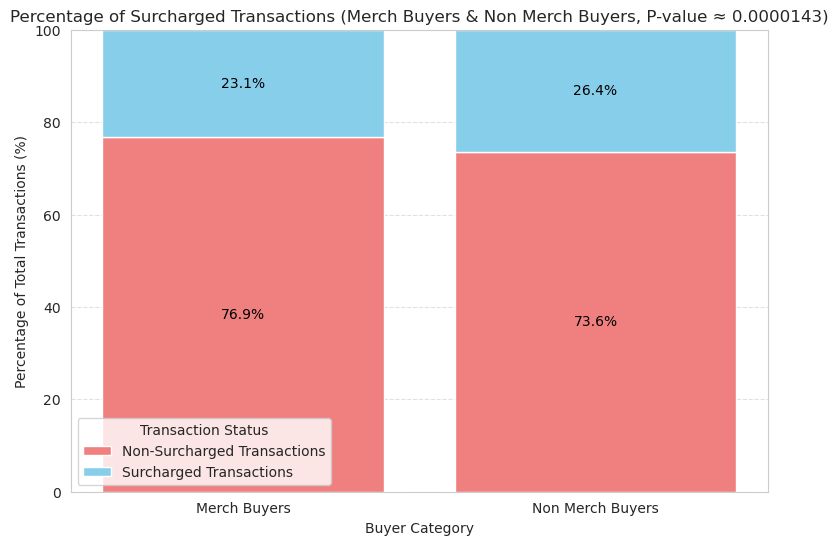

In [207]:
import matplotlib.pyplot as plt
import numpy as np

categories = ['Merch Buyers', 'Non Merch Buyers']
total_transactions_data = np.array([merch_trans, non_merch_trans]) # Example total
surcharged_transactions_data = np.array([sur_merch_trans, sur_non_merch_trans]) # Example surcharge count

non_surcharged_data = total_transactions_data - surcharged_transactions_data

non_surcharged_pct = (non_surcharged_data / total_transactions_data) * 100
surcharged_pct = (surcharged_transactions_data / total_transactions_data) * 100

plt.figure(figsize=(9, 6))

plt.bar(
    categories,
    non_surcharged_pct,
    label='Non-Surcharged Transactions',
    color='lightcoral'
)

plt.bar(
    categories,
    surcharged_pct,
    bottom=non_surcharged_pct,
    label='Surcharged Transactions',
    color='skyblue'
)

for i in range(len(categories)):
    plt.text(
        i,
        non_surcharged_pct[i] / 2,
        f'{non_surcharged_pct[i]:.1f}%',
        ha='center', va='center', fontsize=10, color='black'
    )
    plt.text(
        i,
        non_surcharged_pct[i] + surcharged_pct[i] / 2,
        f'{surcharged_pct[i]:.1f}%',
        ha='center', va='center', fontsize=10, color='black'
    )

plt.ylim(0, 100)

plt.title('Percentage of Surcharged Transactions (Merch Buyers & Non Merch Buyers, P-value ≈ 0.0000143)')
plt.xlabel('Buyer Category')
plt.ylabel('Percentage of Total Transactions (%)')
plt.legend(title='Transaction Status')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

There is a statistically significant (p-value ≈ $0.0000143$) difference in surcharge transactions between patrons who have bought merch and those that have not. This implies that merch sales are driving a conciousness towards sustainability.

To further explore this, we take the bringing of resusable cups as a measure of the rebrand's effectiveness in terms of driving sustainability. Namely, looking into whether the people who buy merch are bringing reusable cups more over their total transactions over those who do not buy merch.

In [220]:
# Use still...

# merch_transactions_df       --> df of transactions for customers who have bought merch
# non_merch_df                --> df of transactions for customers who have NOT bought merch

# &

# merch_trans     --> total transactions of customers who have bought merch
# non_merch_trans --> total transactions of customers who have NOT bought merch

# merch-buyer transactions where reusable cups where brought
cups_merch_trans = len(merch_transactions_df[merch_transactions_df["own_cup"] == True]) 
rate_cups_merch_trans = cups_merch_trans*100/merch_trans

# non merch-buyer transactions where reusable cups where brought
cups_non_merch_trans = len(non_merch_df[non_merch_df["own_cup"] == True]) 
rate_cups_non_merch_trans = cups_non_merch_trans*100/non_merch_trans

print(rate_cups_merch_trans,"%","vs", rate_cups_non_merch_trans, "%")

35.87515516935627 % vs 50.04912797838369 %


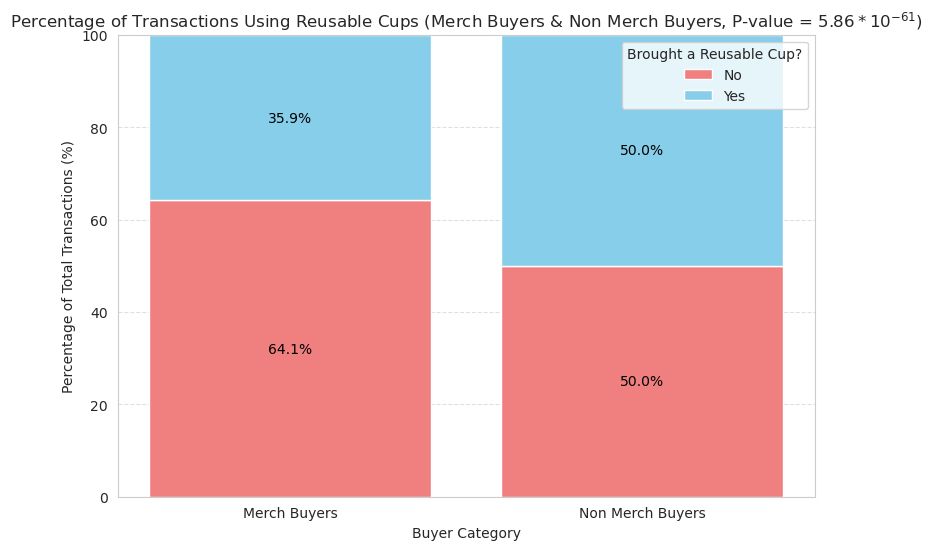

In [219]:
reusable_transactions_data = np.array([cups_merch_trans, cups_non_merch_trans]) # Example surcharge count

non_reusable_data = total_transactions_data - reusable_transactions_data

non_reusable_pct = (non_reusable_data / total_transactions_data) * 100
reusable_pct = (reusable_transactions_data / total_transactions_data) * 100

plt.figure(figsize=(9, 6))

plt.bar(
    categories,
    non_reusable_pct,
    label='No',
    color='lightcoral'
)

plt.bar(
    categories,
    reusable_pct,
    bottom=non_reusable_pct,
    label='Yes',
    color='skyblue'
)

for i in range(len(categories)):
    plt.text(
        i,
        non_reusable_pct[i] / 2,
        f'{non_reusable_pct[i]:.1f}%',
        ha='center', va='center', fontsize=10, color='black'
    )
    plt.text(
        i,
        non_reusable_pct[i] + reusable_pct[i] / 2,
        f'{reusable_pct[i]:.1f}%',
        ha='center', va='center', fontsize=10, color='black'
    )

plt.ylim(0, 100)

plt.title('Percentage of Transactions Using Reusable Cups (Merch Buyers & Non Merch Buyers, P-value = $5.86 * 10^{-61}$)')
plt.xlabel('Buyer Category')
plt.ylabel('Percentage of Total Transactions (%)')
plt.legend(title='Brought a Reusable Cup?')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()